Los hiperparámetros clave a ajustar son:

Tamaño de capa oculta (128)

Tasa de aprendizaje (0.001 por defecto en Adam)

Batch size (64)

Número de épocas (5)

100.0%
100.0%


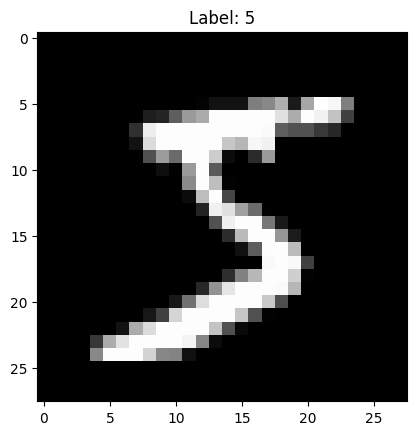

/home/utepsa/Desktop/tayron/ai_classes/ai_classes/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1, Loss: 0.2026
Epoch 2, Loss: 0.1083
Epoch 3, Loss: 0.0488
Epoch 4, Loss: 0.1141
Epoch 5, Loss: 0.0316
Test Accuracy: 0.9768


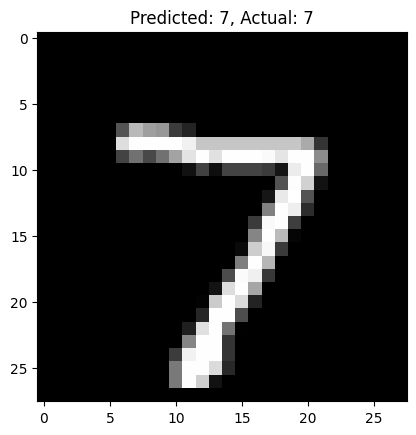

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Load data (directly with PyTorch)
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Display sample image
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

# Simple neural network
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128) # 128 neuronas en la capa oculta
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten
        x = torch.relu(self.fc1(x)) # Función de activación no lineal
        #Introduce no linealidad en la red. Otras opciones serían LeakyReLU, Sigmoid o Tanh.
        x = self.fc2(x)
        return x

model = Net()
# Función de pérdida
criterion = nn.CrossEntropyLoss() # Usado para clasificación multiclase
optimizer = optim.Adam(model.parameters()) # Por defecto la tasa de aprendizaje lr=0.001
# Alternativas: SGD, RMSprop. Adam suele ser una opción robusta por defecto.

# Data loaders
# 64 es el numero de elementos por lote
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

# Training loop
for epoch in range(5):  # la cantidad de epocas
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Evaluation
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {correct/total:.4f}")

# Display a test prediction
image, label = test_data[0]
with torch.no_grad():
    output = model(image.unsqueeze(0))
    prediction = torch.argmax(output).item()

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Predicted: {prediction}, Actual: {label}")
plt.show()